# Data augmentation with ASL dataset

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will use data augmentation techniques to improve the performance of our model on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [3]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "./data/asl/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

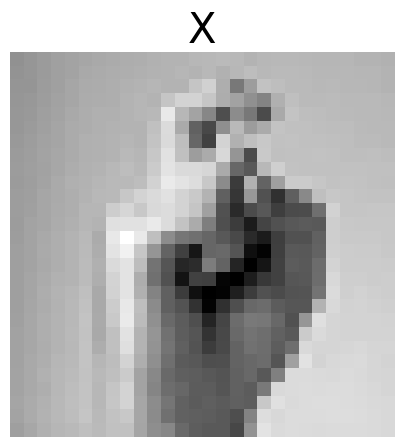

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train_no_augmentation(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

To avoid repeating code, we can define a custom class for each convolutional block (conv layer, activation, and pooling) and then use it to build our CNN model.

In [13]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        super().__init__()
        kernel_size = 3

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [14]:
model_cnn = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [15]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train_no_augmentation(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:55<00:00,  2.79s/epoch, train_acc=0.9980, train_loss=0.0067, val_acc=0.9487, val_loss=0.2226]


In [16]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

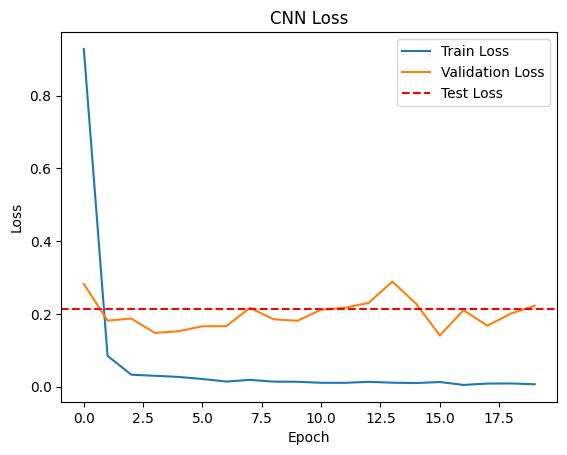

In [17]:
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Data Augmentation

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of the existing data. This can help improve the generalization of a model and reduce overfitting, especially when the original dataset is small.

The increase in size gives the model more images to learn from while training. The increase in variance helps the model ignore unimportant features and select only the features that are truly important in classification, allowing it to generalize better.

### Random resized crop

This transform will randomly resize the input image based on `scale`, and then crop it to a size we specify. In this case, we will crop it to the original image dimensions. To do this, TorchVision needs to know the aspect ratio of the image it is scaling. Since our height is the same as our width, our aspect `ratio` is 1:1.

In [18]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

In [19]:
def compare_images(_img, t):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(F.to_pil_image(_img), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    img_transformed = t(_img).cpu()
    axes[1].imshow(F.to_pil_image(img_transformed), cmap='gray')
    axes[1].set_title("Transformed Image")
    axes[1].axis('off')
    plt.show()

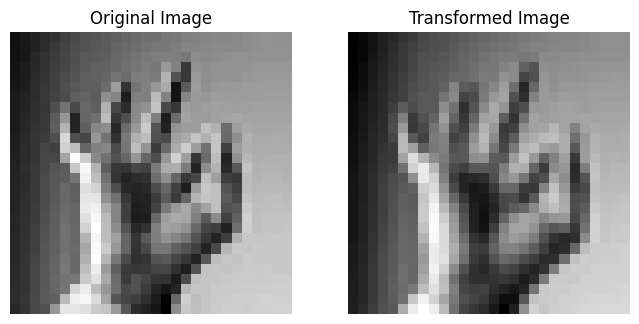

In [20]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random horizontal flip

We can also randomly flip our images [Horizontally](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomHorizontalFlip) or [Vertically](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomVerticalFlip). However, for these images, we will only flip them horizontally.

American Sign Language can be done with either the left or right hand being dominant. However, it is unlikely to see sign language from upside down. This kind of domain-specific reasoning can help make good decisions for your own deep learning applications.

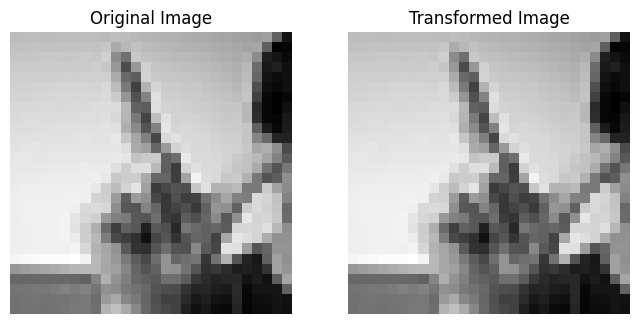

In [21]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random rotation

We can also randomly rotate the image to add more variability. Just like with with other augmentation techniques, it's easy to accidentally go too far. With ASL, if we rotate too much, our `D`s might look like `G`s and visa versa. Because of this, let's limit it to `30` degrees.

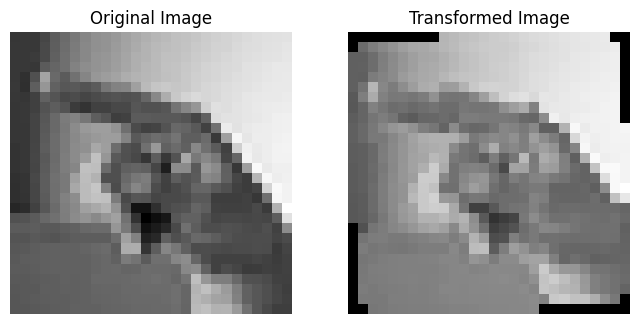

In [22]:
trans = transforms.Compose([
    transforms.RandomRotation(30)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Color jitter

The `ColorJitter` transform has 4 arguments:, brightness, contrast, saturation and hue


The latter 2 apply to color images, so we will only use the first 2 for now.

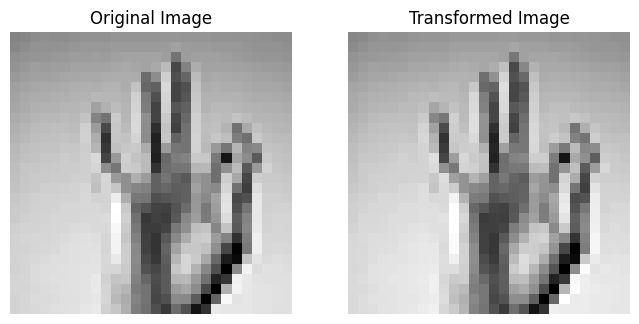

In [23]:
brightness = .2  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

## Training with augmentation

Data augmentation occurs during the training loop, where the defined transformations are applied to the training images. We will create a new training function that includes an extra argument with the transformations, and applies them to each batch of training data before feeding it into the model.

In [24]:
def train_with_augmentation(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

Let's also define our transformations in a single variable so we can easily pass it to our training function.

In [25]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

We can also visualize the transformations to see how they are changing the images.

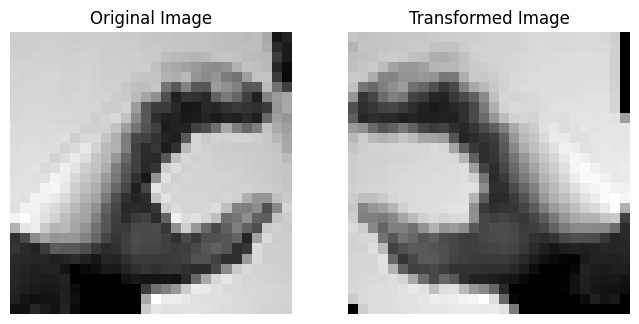

In [26]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), random_transforms)

Now we can train the CNN model again, but this time with the defined augmentations applied to the training data.

Note that the augmentation only applies during training, so the test method remains unchanged. Also, this transformation pipeline is inherent to the training loop, so it should not be included in the Dataset or the model itself, as it is only relevant during training.

In [27]:
model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

In [28]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train_with_augmentation(model_cnn_aug, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [01:21<00:00,  4.06s/epoch, train_acc=0.9778, train_loss=0.0709, val_acc=0.9780, val_loss=0.0574]


In [29]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

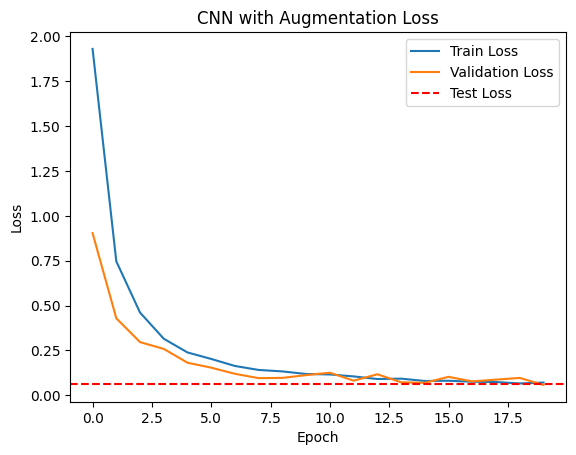

In [30]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reflection section

### What impact did data augmentation had on the model performance?

La implementación de Data Augmentation en el modelo tuvo un gran impacto en el desempeño del modelo. Se puede aprecir en las curvas de aprendizaje de ambos modelos (con y sin data augmentation) que la mejora fue bastante considerable. Sin data augmentation el modelo llegó a sufrir de overfitting bastante rápido (durante las primeras épocas). Además, si bien, los valores de pérdida no fueron tan malos (al menos a mi criterio), el modelo tenía mucho margen de mejora. Al implementar data augmentation se consiguió un modelo que no sufre de overfitting, al contrario, el desempeño del modelo mejora con cada época y en ningún momento de las 20 épocas se nota un cambio en esta tendencia. Además, el valor de pérdida final del modelo resultante fue considerablemente mejor que el anterior.

### Re-run training with a smaller subset of train data (both with augmentation and without it)

In [31]:
# Obtener subconjunto de datos (10 mil datos)

from torch.utils.data import Subset
import numpy as np

subset_size = 10000

indices = np.random.choice(len(train_data), subset_size, replace=False)

train_subset = Subset(train_data, indices)

train_loader_subset = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

In [32]:
# Re-entrenar modelo sin data augmentation

model_cnn = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train_no_augmentation(model_cnn, train_loader_subset, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:21<00:00,  1.09s/epoch, train_acc=0.9968, train_loss=0.0075, val_acc=0.9576, val_loss=0.1607]


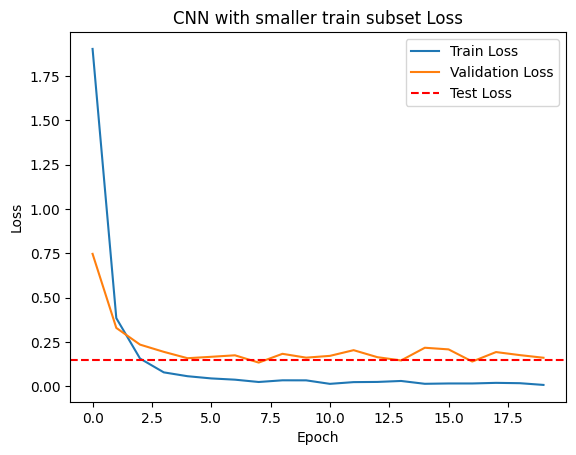

In [33]:
# Desplegar curvas de aprendizaje para modelo sin data augmentation

cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN with smaller train subset Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [34]:
# Re-entrenar modelo con data augmentation

model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train_with_augmentation(model_cnn_aug, train_loader_subset, val_loader, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [00:32<00:00,  1.61s/epoch, train_acc=0.9544, train_loss=0.1357, val_acc=0.9367, val_loss=0.1872]


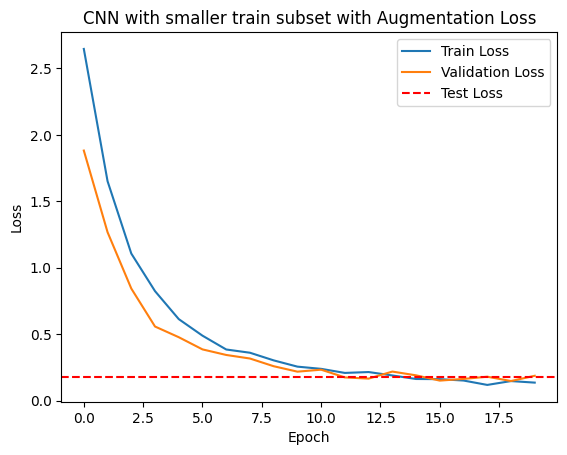

In [35]:
# Desplegar curvas de aprendizaje para modelo con data augmentation

cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with smaller train subset with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Utilizando un subconjunto más pequeño de hecho el modelo sin data augmentation tuvo un desempeño mejor que el  modelo sin data augmentation que usó el conjunto de datos de entrenamiento completo, incluso a pesar de haber sufrido de overfitting. De hecho en validación el modelo sin esta técnica tuvo un mejor rendimiento que el modelo que si la usa, aunque la diferencia no fue demasiado grande. Sorpresivamente tener menos datos hizo que ambos modelos tuvieran un mejor desempeño, aunque desconozco el por qué pasa esto.

### Re-train the model using a different transformation pipeline for augmentation

Refer to the following documentation page: https://docs.pytorch.org/vision/stable/transforms.html

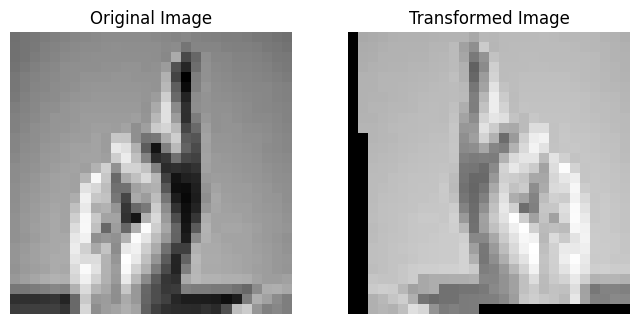

In [36]:
# Definir nuevo pipeline de transformaciones y probarlas

random_transforms_2 = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.15, contrast=0.3),
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), random_transforms_2)

In [37]:
# Entrenar el modelo

model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train_with_augmentation(model_cnn_aug, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms_2)

Training: 100%|██████████| 20/20 [01:24<00:00,  4.21s/epoch, train_acc=0.9625, train_loss=0.1160, val_acc=0.9969, val_loss=0.0194]


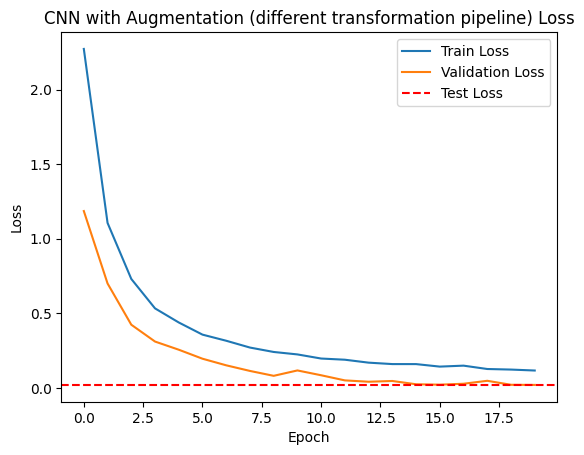

In [38]:
# Desplegar curvas de aprendizaje

cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation (different transformation pipeline) Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Al utilizar este pipeline de trnaformaciones distinto, los resultados del modelo fueron mejores que usando el antiguo pipeline. De hecho el resultado fue muy similar al del modelo con data augmentation que utilizó el subconjunto de entrenamiento.

### Write down your final remarks

Al realizar esta actividad pude aprender a utilizar la técnica de data augmentation en una red neuronal convolucional. Me parece que esta técnica es sumamente valiosa ya que permite darle más variedad y cantidad al conjunto de datos de entrenamiento. Me sorprendió mucho lo efectiva que resultó ser esta técnica, por lo menos en el problema de esta actividad. Los resultados superaron mis expectativas, mejorando bastante los resultados de evaluación del modelo. Por otro lado, también me sorpendió que utilizar un conjunto de datos más pequeño para el entrenamiento haya resultado tener un impacto positivo en los modelos (tanto con y sin data augmentation). No comprendo muy bien por qué podría pasar esto, pero me parece que incluso minimizó la gravedad del overfitting del modelo sin data augmentation, haciendo que los valores de pérdida comenzaran a oscilar pero sin mucha diferencia, se puede decir que el valor se mantuvo estable. En general me parece una técnica muy valiosa que nos será sumamente útil para nuestros proyectos.